<a href="https://colab.research.google.com/github/franz-ops/IoT-Traffic-Analyzer-/blob/main/IoT_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Download Dataset**

Opzioni:

1) Downlaod del dataset e estrazione

2) Importazione del dataset da Drive e estrazione

1) Download del dataset e estrazione

In [ ]:
!wget https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz

In [ ]:
import tarfile 
file = tarfile.open('iot_23_datasets_small.tar.gz') 
  
# extracting file 
file.extractall('./') 
  
file.close() 

In [ ]:
!rm "/content/iot_23_datasets_small.tar.gz"

2) Importazione dataset da Drive e estrazione

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tarfile 
file = tarfile.open('drive/MyDrive/IoT23/iot_23_datasets_small.tar.gz') 
  
# extracting file 
file.extractall('./') 
  
file.close() 

In [ ]:
!mv "/content/opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-7-1/Somfy-01/bro" "/content/opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-7-1/"
!rmdir "/content/opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-7-1/Somfy-01"

In [ ]:
!pip install zat

     |████████████████████████████████| 461 kB 5.0 MB/s 
     |████████████████████████████████| 76 kB 5.3 MB/s 


In [ ]:
!python -c "import zat as _; print(_.__path__)"

['/usr/local/lib/python3.7/dist-packages/zat']


Ora cercare il file log_to_dataframe.py e modificare la riga 48 inserendo come parametro della read_csv: 
nrows=20000

In [ ]:
from zat.log_to_dataframe import LogToDataFrame
import pandas as pd
import os

path = r"/content/opt/Malware-Project/BigDataset/IoTScenarios/"
path_list = []

directories = os.listdir( path )
 
for file in directories:
  path_list.append("/content/opt/Malware-Project/BigDataset/IoTScenarios/"+file+"/bro/conn.log.labeled")


log_to_df = LogToDataFrame()
df = log_to_df.create_dataframe(path_list[0])
#print(df)

for i in range (1, len(path_list)):
  df2 = log_to_df.create_dataframe(path_list[i])
  #print("Dataset "+path_list[i])
  #print(df2)
  df = df.append(df2)

df.index = range(df.index.size)
df.columns = ["uid","id.orig_h","id.orig_p","id.resp_h","id.resp_p","proto","service","duration",
                        "orig_bytes","resp_bytes","conn_state","local_orig","local_resp","missed_bytes","history"
                        ,"orig_pkts","orig_ip_bytes","resp_pkts","resp_ip_bytes","col"]
df[['tunnel_parents','label','detailed-label']] = pd.DataFrame(df.col.str.split('\s+',2).tolist(), columns=['tunnel_parents','label','detailed-label'])  
df = df.drop(axis=1, columns=["col","uid"])
df                      

,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label
0,192.168.2.5,38792,200.168.87.203,59353,tcp,NaN,0 days 00:00:02.998333,0,0,S0,NaN,NaN,0,S,3,180,0,0,(empty),Malicious,PartOfAHorizontalPortScan
1,192.168.2.5,38792,200.168.87.203,59353,tcp,NaN,NaT,<NA>,<NA>,S0,NaN,NaN,0,S,1,60,0,0,(empty),Malicious,PartOfAHorizontalPortScan
2,192.168.2.5,38793,200.168.87.203,59353,tcp,NaN,0 days 00:00:02.997182,0,0,S0,NaN,NaN,0,S,3,180,0,0,(empty),Malicious,PartOfAHorizontalPortScan
3,192.168.2.5,38793,200.168.87.203,59353,tcp,NaN,NaT,<NA>,<NA>,S0,NaN,NaN,0,S,1,60,0,0,(empty),Malicious,PartOfAHorizontalPortScan
4,192.168.2.5,38794,200.168.87.203,59353,tcp,NaN,0 days 00:00:02.996286,0,0,S0,NaN,NaN,0,S,3,180,0,0,(empty),Malicious,PartOfAHorizontalPortScan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323512,192.168.1.200,50288,45.94.122.135,23,tcp,NaN,0 days 00:00:00.000001,0,0,S0,NaN,NaN,0,S,2,120,0,0,-,Malicious,PartOfAHorizontalPortScan
323513,192.168.1.200,49128,44.93.121.134,23,tcp,NaN,0 days 00:00:00.000002,0,0,S0,NaN,NaN,0,S,2,120,0,0,-,Malicious,PartOfAHorizontalPortScan
323514,192.168.1.200,36458,43.92.120.133,23,tcp,NaN,0 days 00:00:00.000002,0,0,S0,NaN,NaN,0,S,2,120,0,0,-,Malicious,PartOfAHorizontalPortScan
323515,192.168.1.200,50220,42.91.119.132,23,tcp,NaN,0 days 00:00:00.000001,0,0,S0,NaN,NaN,0,S,2,120,0,0,-,Malicious,PartOfAHorizontalPortScan


In [ ]:
import pandas as pd
import os

path = r"/content/opt/Malware-Project/BigDataset/IoTScenarios/"
path_list = []

directories = os.listdir( path )
 
for file in directories:
  path_list.append("/content/opt/Malware-Project/BigDataset/IoTScenarios/"+file+"/bro/conn.log.labeled")


df = pd.read_csv(path_list[0], sep="\s+", skiprows=8, nrows=20000, names=["ts", "uid","id.orig_h","id.orig_p","id.resp_h","id.resp_p","proto","service","duration",
                        "orig_bytes","resp_bytes","conn_state","local_orig","local_resp","missed_bytes","history"
                        ,"orig_pkts","orig_ip_bytes","resp_pkts","resp_ip_bytes","tunnel_parents","label","detailed-label"], 
                         comment="#", na_values='-')

df = df.drop(axis=1, columns=["uid", "ts"])
df = df[:-1]
#print(df)
for i in range (1, len(path_list)):
  df2 = pd.read_csv(path_list[i], sep="\s+", skiprows=8, nrows=20000, names=["ts", "uid","id.orig_h","id.orig_p","id.resp_h","id.resp_p","proto","service","duration",
                        "orig_bytes","resp_bytes","conn_state","local_orig","local_resp","missed_bytes","history","orig_pkts","orig_ip_bytes","resp_pkts",
                        "resp_ip_bytes","tunnel_parents","label","detailed-label"],
                         comment="#", na_values='-')
  df2 = df2.drop(axis=1, columns=["uid", "ts"])
  df2 = df2[:-1]
  #print("Dataset "+path_list[i])
  #print(df2)
  df = df.append(df2)
  
df


In [ ]:
display(df.dtypes)

id.orig_h                  object
id.orig_p                  UInt16
id.resp_h                  object
id.resp_p                  UInt16
proto                      object
service                    object
duration          timedelta64[ns]
orig_bytes                 UInt64
resp_bytes                 UInt64
conn_state                 object
local_orig               category
local_resp               category
missed_bytes               UInt64
history                    object
orig_pkts                  UInt64
orig_ip_bytes              UInt64
resp_pkts                  UInt64
resp_ip_bytes              UInt64
tunnel_parents             object
label                      object
detailed-label             object
dtype: object

In [ ]:
df = df.convert_dtypes()

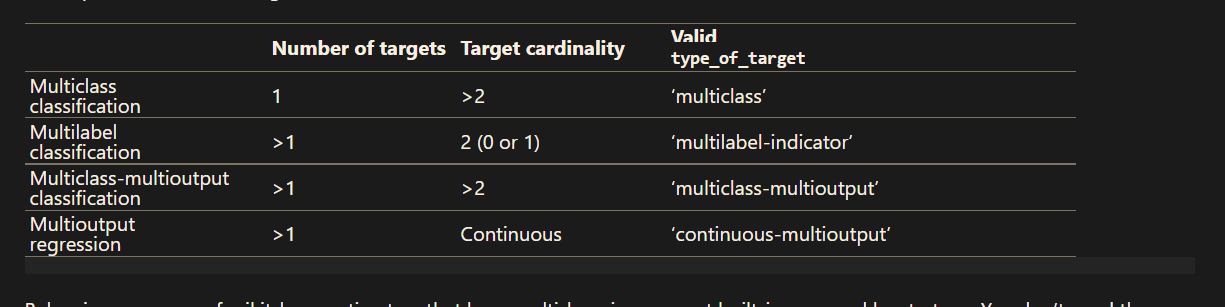

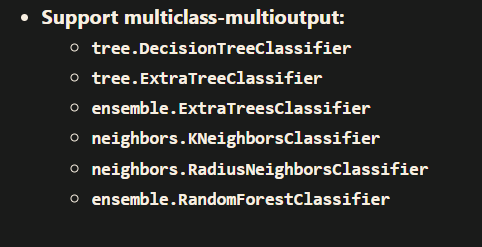

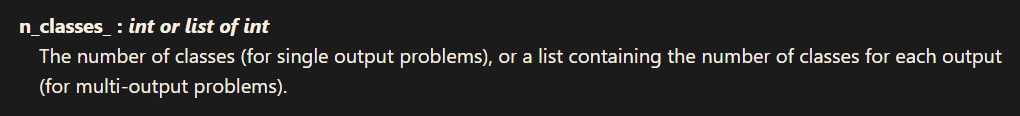

Creo una One Hot Encoding della colonna label:
- 0 = "Benign"
- 1 = "Malicious"

E una Label Encoding per la colonna detailed-label:
- 0 = None 
- 1 = Attack	
- 2 = C&C	
- 3 = C&C-FileDownload	
- 4 = C&C-HeartBeat	
- 5 = C&C-HeartBeat-FileDownload	
- 6 = C&C-Mirai	
- 7 = C&C-Torii	
- 8 = DDoS	
- 9 = FileDownload	
- 10 = Okiru	
- 11 = PartOfAHorizontalPortScan

Protocolli:
- 0 = icmp
- 1 = tcp
- 2 = udp

Servizio:
- 0 = dhcp
- 1 = dns
- 2 = http
- 3 = irc
- 4 = ssh
- 5 = ssl
- 6 = NaN

Connection state:
- 0 = OTH
- 1 = REJ
- 2 = RSTO
- 3 = RSTOS0
- 4 = RSTR
- 5 = RSTRH
- 6 = S0
- 7 = S1
- 8 = S2
- 9 = S3
- 10 = SF
- 11 = SH
- 12 = SHR

In [ ]:
# Creiamo una One Hot Encoding per la colonna Label
df['label'] = df['label'].str.title()
dummy1 = pd.get_dummies(df['label'], drop_first=True)
df['label'] = dummy1
df

,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label
0,192.168.2.5,38792,200.168.87.203,59353,tcp,NaN,0 days 00:00:02.998333,0,0,S0,NaN,NaN,0,S,3,180,0,0,(empty),1,PartOfAHorizontalPortScan
1,192.168.2.5,38792,200.168.87.203,59353,tcp,NaN,NaT,<NA>,<NA>,S0,NaN,NaN,0,S,1,60,0,0,(empty),1,PartOfAHorizontalPortScan
2,192.168.2.5,38793,200.168.87.203,59353,tcp,NaN,0 days 00:00:02.997182,0,0,S0,NaN,NaN,0,S,3,180,0,0,(empty),1,PartOfAHorizontalPortScan
3,192.168.2.5,38793,200.168.87.203,59353,tcp,NaN,NaT,<NA>,<NA>,S0,NaN,NaN,0,S,1,60,0,0,(empty),1,PartOfAHorizontalPortScan
4,192.168.2.5,38794,200.168.87.203,59353,tcp,NaN,0 days 00:00:02.996286,0,0,S0,NaN,NaN,0,S,3,180,0,0,(empty),1,PartOfAHorizontalPortScan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323512,192.168.1.200,50288,45.94.122.135,23,tcp,NaN,0 days 00:00:00.000001,0,0,S0,NaN,NaN,0,S,2,120,0,0,-,1,PartOfAHorizontalPortScan
323513,192.168.1.200,49128,44.93.121.134,23,tcp,NaN,0 days 00:00:00.000002,0,0,S0,NaN,NaN,0,S,2,120,0,0,-,1,PartOfAHorizontalPortScan
323514,192.168.1.200,36458,43.92.120.133,23,tcp,NaN,0 days 00:00:00.000002,0,0,S0,NaN,NaN,0,S,2,120,0,0,-,1,PartOfAHorizontalPortScan
323515,192.168.1.200,50220,42.91.119.132,23,tcp,NaN,0 days 00:00:00.000001,0,0,S0,NaN,NaN,0,S,2,120,0,0,-,1,PartOfAHorizontalPortScan


In [ ]:
# Creiamo una One Hot Encoding per la colonna detailed-label e proto
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['detailed-label'] = le.fit_transform(df['detailed-label'])
df['proto'] = le.fit_transform(df['proto'])
df['service'] = le.fit_transform(df['service'])
df['conn_state'] = le.fit_transform(df['conn_state'])

In [ ]:
X = df[df.columns[:-2]]
print(X)

        id.orig_p  id.resp_p  proto  ...  orig_ip_bytes resp_pkts  resp_ip_bytes
0           38792      59353      1  ...            180         0              0
1           38792      59353      1  ...             60         0              0
2           38793      59353      1  ...            180         0              0
3           38793      59353      1  ...             60         0              0
4           38794      59353      1  ...            180         0              0
...           ...        ...    ...  ...            ...       ...            ...
323512      50288         23      1  ...            120         0              0
323513      49128         23      1  ...            120         0              0
323514      36458         23      1  ...            120         0              0
323515      50220         23      1  ...            120         0              0
323516      59864         23      1  ...            120         0              0

[323517 rows x 13 columns]


In [ ]:
y = df[df.columns[-2:]]
print(y)

        label  detailed-label
0           1              11
1           1              11
2           1              11
3           1              11
4           1              11
...       ...             ...
323512      1              11
323513      1              11
323514      1              11
323515      1              11
323516      1              11

[323517 rows x 2 columns]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

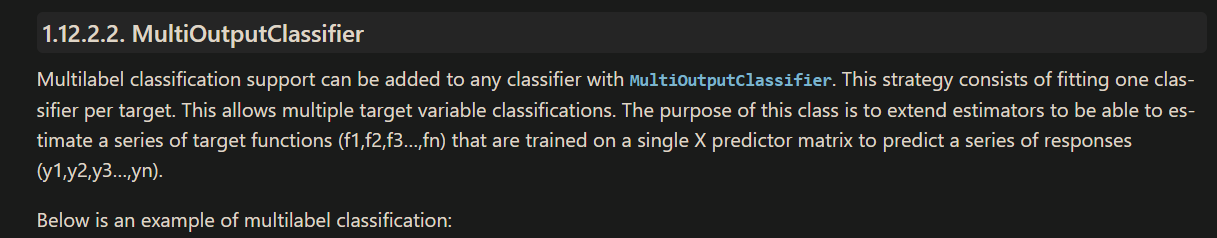

In [ ]:
y1 = df[df.columns[-2:-1]]
print(y1)

In [ ]:
y2 = df[df.columns[-1:]]
print(y2)

In [ ]:
from sklearn.datasets import make_multilabel_classification
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
import numpy as np
X, y = make_multilabel_classification(n_samples=20000, n_features=9, n_classes=2, random_state=0)

for i in range(10): 
  print(X[i]," => ", y[i])

[ 3. 11. 10.  1.  5. 11.  1.  4.  4.]  =>  [0 1]
[ 4.  3.  9.  6. 18.  5.  1.  1.  7.]  =>  [1 0]
[ 9.  6.  8.  8.  6. 11.  0.  1.  8.]  =>  [1 1]
[ 5.  6.  9.  5.  9.  6.  0.  3. 14.]  =>  [1 1]
[8. 6. 8. 8. 4. 9. 1. 0. 5.]  =>  [1 0]
[1. 3. 4. 7. 6. 6. 1. 1. 8.]  =>  [1 1]
[ 8.  4. 10.  7.  3.  6.  0.  2.  7.]  =>  [1 1]
[ 3.  3. 11. 12.  7.  4.  2.  1. 11.]  =>  [1 1]
[ 6.  5.  6.  3.  5.  9.  3.  3. 11.]  =>  [0 1]
[7. 4. 7. 9. 7. 8. 1. 2. 9.]  =>  [1 1]


In [ ]:
forest = RandomForestClassifier(random_state=1)
#multi_target_forest = MultiOutputClassifier(forest, n_jobs=-1)
multi_target_forest = MultiOutputClassifier(forest)
print(multi_target_forest)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=1))


In [ ]:
multi_target_forest.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=1))

In [ ]:
y_test['label'].to_numpy().astype(float)
y_test['detailed-label'].to_numpy().astype(float)

IndexError: ignored

In [ ]:

multi_target_forest.predict()

In [ ]:
df = df.select_dtypes(exclude=['object'])
df

,id.orig_p,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,local_orig,local_resp,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,detailed-label
0,38792,59353,1,6,0 days 00:00:02.998333,0,0,6,NaN,NaN,0,3,180,0,0,1,11
1,38792,59353,1,6,NaT,<NA>,<NA>,6,NaN,NaN,0,1,60,0,0,1,11
2,38793,59353,1,6,0 days 00:00:02.997182,0,0,6,NaN,NaN,0,3,180,0,0,1,11
3,38793,59353,1,6,NaT,<NA>,<NA>,6,NaN,NaN,0,1,60,0,0,1,11
4,38794,59353,1,6,0 days 00:00:02.996286,0,0,6,NaN,NaN,0,3,180,0,0,1,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323512,50288,23,1,6,0 days 00:00:00.000001,0,0,6,NaN,NaN,0,2,120,0,0,1,11
323513,49128,23,1,6,0 days 00:00:00.000002,0,0,6,NaN,NaN,0,2,120,0,0,1,11
323514,36458,23,1,6,0 days 00:00:00.000002,0,0,6,NaN,NaN,0,2,120,0,0,1,11
323515,50220,23,1,6,0 days 00:00:00.000001,0,0,6,NaN,NaN,0,2,120,0,0,1,11


In [ ]:
df['tunnel_parents'].value_counts(dropna=False)

KeyError: ignored

In [ ]:
df['service'].value_counts(dropna=False)

6    315273
1      5371
3      1231
4      1025
2       344
0       178
5        95
Name: service, dtype: int64

In [ ]:
df['local_resp'].value_counts(dropna=False)

NaN    323517
Name: local_resp, dtype: int64

In [ ]:
df['duration'].value_counts(dropna=False)

NaT                       198898
0 days 00:00:00.000002     36682
0 days 00:00:00.000005     10716
0 days 00:00:00.000001      6426
0 days 00:00:00.000006      5345
                           ...  
0 days 00:00:04.088421         1
0 days 00:00:02.999524         1
0 days 00:00:03.090275         1
0 days 00:00:03.140705         1
0 days 00:00:03.092267         1
Name: duration, Length: 26991, dtype: int64

In [ ]:
df['resp_bytes'].value_counts(dropna=False)

NaN       198898
0         110243
48          6039
45          2808
243          896
           ...  
129941         1
152039         1
110211         1
5870           1
59             1
Name: resp_bytes, Length: 381, dtype: Int64

In [ ]:
df['history'].value_counts(dropna=False)

KeyError: ignored

In [ ]:
df['label'].value_counts(dropna=False)

1    268384
0     55133
Name: label, dtype: int64

In [ ]:
df = df.drop(axis=1, columns=["tunnel_parents","id.orig_h","id.resp_h","local_orig","local_resp","history"])
df['duration'] = df['duration'].fillna(pd.Timedelta(seconds=0))
df['orig_bytes'] = df['orig_bytes'].fillna(0)
df['resp_bytes'] = df['resp_bytes'].fillna(0)

In [ ]:
df = df.drop(axis=1, columns=["history"])

In [ ]:
df

,id.orig_p,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,detailed-label
0,38792,59353,1,6,0 days 00:00:02.998333,0,0,6,0,3,180,0,0,1,11
1,38792,59353,1,6,0 days 00:00:00,0,0,6,0,1,60,0,0,1,11
2,38793,59353,1,6,0 days 00:00:02.997182,0,0,6,0,3,180,0,0,1,11
3,38793,59353,1,6,0 days 00:00:00,0,0,6,0,1,60,0,0,1,11
4,38794,59353,1,6,0 days 00:00:02.996286,0,0,6,0,3,180,0,0,1,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323512,50288,23,1,6,0 days 00:00:00.000001,0,0,6,0,2,120,0,0,1,11
323513,49128,23,1,6,0 days 00:00:00.000002,0,0,6,0,2,120,0,0,1,11
323514,36458,23,1,6,0 days 00:00:00.000002,0,0,6,0,2,120,0,0,1,11
323515,50220,23,1,6,0 days 00:00:00.000001,0,0,6,0,2,120,0,0,1,11


In [ ]:
y = df[df.columns[-2:-1]]
print(y)

In [ ]:
X = df[df.columns[:-2]]
print(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [ ]:
X_train = X_train.convert_dtypes()
X_test = X_test.convert_dtypes()
y_train = y_train.convert_dtypes()
y_test = y_test.convert_dtypes()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# creating a RF classifier
clf = RandomForestClassifier(n_estimators = 100) 
 
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)
 
# performing predictions on the test dataset
y_pred = clf.predict(X_test)
# metrics are used to find accuracy or error
from sklearn import metrics 
print()
 
# using metrics module for accuracy calculation
print("ACCURACY OF THE MODEL: ", metrics.accuracy_score(y_test['label'].to_numpy().astype(float), y_pred))
print(metrics.classification_report(y_test['label'].to_numpy().astype(float), y_pred))

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  import sys



ACCURACY OF THE MODEL:  0.9898745796686056
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97     18312
         1.0       0.99      1.00      0.99     88449

    accuracy                           0.99    106761
   macro avg       0.99      0.98      0.98    106761
weighted avg       0.99      0.99      0.99    106761



In [ ]:
print(y_pred)

[1. 0. 1. ... 1. 0. 1.]


In [ ]:
print(y_test['label'].to_numpy().astype(float))

[1. 0. 1. ... 1. 0. 1.]
